# Titanic Dataset – Exploratory Data Analysis (EDA)

## Data Analytics Internship Program – Week 2

### Author
Noor-ul-Ain

### Tools Used
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

# Objective

To perform Exploratory Data Analysis (EDA) on the cleaned Titanic dataset, discover meaningful patterns, answer business questions using visualizations, and generate business insights and recommendations.

# Import Required Libraries

In this section, the required Python libraries are imported to perform data analysis, visualization, and feature engineering.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

The cleaned Titanic dataset created in Week 1 is loaded into Google Colab for Exploratory Data Analysis (EDA).

In [4]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_titanic.csv to cleaned_titanic.csv


In [5]:
df = pd.read_csv("cleaned_titanic.csv")

# Part 1 – Data Understanding

The purpose of this section is to understand the structure, content, and quality of the dataset before performing Exploratory Data Analysis (EDA).

## Display First Five Rows

The first five records of the dataset are displayed to understand the structure and available information.

In [6]:
df.head()

,Passenger_ID,Survived,Passenger_Class,Name,Sex,Age,Siblings_Spouses,Parents_Children,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Display Last Five Rows

The last five records are displayed to verify the dataset's ending entries.

In [6]:
df.tail()

,Passenger_ID,Survived,Passenger_Class,Name,Sex,Age,Siblings_Spouses,Parents_Children,Ticket,Fare,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.45,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q


## Dataset Shape

The shape of the dataset is checked to determine the total number of rows and columns.

In [7]:
df.shape

(891, 11)

## Column Names

The names of all columns are displayed to understand the available features used for analysis.

In [8]:
df.columns

Index(['Passenger_ID', 'Survived', 'Passenger_Class', 'Name', 'Sex', 'Age',
       'Siblings_Spouses', 'Parents_Children', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

## Dataset Information

The information function is used to verify data types and ensure that each feature is stored in an appropriate format.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Passenger_ID      891 non-null    int64  
 1   Survived          891 non-null    int64  
 2   Passenger_Class   891 non-null    int64  
 3   Name              891 non-null    object 
 4   Sex               891 non-null    object 
 5   Age               891 non-null    float64
 6   Siblings_Spouses  891 non-null    int64  
 7   Parents_Children  891 non-null    int64  
 8   Ticket            891 non-null    object 
 9   Fare              891 non-null    float64
 10  Embarked          891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB



## Summary Statistics

Descriptive statistics are generated to understand the numerical characteristics of the dataset.

In [10]:
df.describe()

,Passenger_ID,Survived,Passenger_Class,Age,Siblings_Spouses,Parents_Children,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Missing Values

The dataset is checked for any remaining missing values after the cleaning process.

In [11]:
df.isnull().sum()

,0
Passenger_ID,0
Survived,0
Passenger_Class,0
Name,0
Sex,0
Age,0
Siblings_Spouses,0
Parents_Children,0
Ticket,0
Fare,0


## Duplicate Records

Duplicate records are checked to ensure data consistency.

In [12]:
df.duplicated().sum()

np.int64(0)

# Part 2 – Feature Engineering

Feature engineering is the process of creating new features from existing data to improve analysis and gain deeper insights. In this section, new columns are created to better understand passenger characteristics and survival patterns.

## Feature 1 – Family Size

A new feature called **FamilySize** is created by combining the number of siblings/spouses and parents/children travelling with each passenger, including the passenger themselves.

In [9]:
df["FamilySize"] = df["Siblings_Spouses"] + df["Parents_Children"] + 1

In [10]:
df[["Siblings_Spouses", "Parents_Children", "FamilySize"]].head()

,Siblings_Spouses,Parents_Children,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


## Feature 2 – Is Alone

This feature identifies whether a passenger was travelling alone or with family members. It helps us compare the survival patterns of passengers travelling alone and those travelling with family.

In [11]:
df["IsAlone"] = np.where(df["FamilySize"] == 1, "Yes", "No")

In [12]:
df[["FamilySize", "IsAlone"]].head(10)

,FamilySize,IsAlone
0,2,No
1,2,No
2,1,Yes
3,2,No
4,1,Yes
5,1,Yes
6,1,Yes
7,5,No
8,3,No
9,2,No


## Feature 3 – Age Group

Passengers are divided into different age categories to make it easier to compare survival patterns among children, teenagers, adults, and senior citizens.

In [13]:
def age_group(age):
    if age < 13:
        return "Child"
    elif age < 20:
        return "Teenager"
    elif age < 60:
        return "Adult"
    else:
        return "Senior Citizen"

df["AgeGroup"] = df["Age"].apply(age_group)

In [14]:
df[["Age", "AgeGroup"]].head(15)

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult
5,28.0,Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Adult
9,14.0,Teenager


## Feature 4 – Fare Category

Passengers are grouped into fare categories based on their ticket prices. This allows us to investigate whether passengers paying different fare levels experienced different survival patterns.

In [15]:
def fare_category(fare):
    if fare <= 20:
        return "Low Fare"
    elif fare <= 50:
        return "Medium Fare"
    else:
        return "High Fare"

df["FareCategory"] = df["Fare"].apply(fare_category)

In [16]:
df[["Fare", "FareCategory"]].head(15)

,Fare,FareCategory
0,7.2500,Low Fare
1,71.2833,High Fare
2,7.9250,Low Fare
3,53.1000,High Fare
4,8.0500,Low Fare
5,8.4583,Low Fare
6,51.8625,High Fare
7,21.0750,Medium Fare
8,11.1333,Low Fare
9,30.0708,Medium Fare


In [17]:
df.head()

,Passenger_ID,Survived,Passenger_Class,Name,Sex,Age,Siblings_Spouses,Parents_Children,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,FareCategory
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,No,Adult,Low Fare
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,No,Adult,High Fare
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Yes,Adult,Low Fare
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,No,Adult,High Fare
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Yes,Adult,Low Fare


In [18]:
df.shape

(891, 15)

# Part 3 – Exploratory Data Analysis

In this section, the Titanic dataset is analyzed using statistical calculations and visualizations to identify survival patterns and relationships between different passenger characteristics.

## Question 1 – What Percentage of Passengers Survived?

This analysis determines the proportion of passengers who survived and those who did not survive the Titanic disaster.

In [19]:
survival_percentage = df["Survived"].value_counts(normalize=True) * 100

survival_percentage

,proportion
Survived,
0,61.616162
1,38.383838


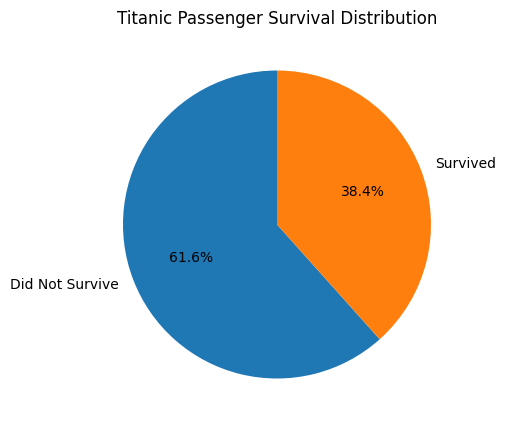

In [20]:
survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(7, 5))

plt.pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Titanic Passenger Survival Distribution")
plt.show()

### Observation

Approximately 38.4% of the passengers survived, while around 61.6% did not survive. This shows that the majority of passengers did not survive the Titanic disaster. The survival rate was therefore considerably lower than the non-survival rate.

## Question 2 – Which Gender Had the Highest Survival Rate?

This analysis compares the survival rates of male and female passengers to determine whether gender was associated with survival.

In [21]:
gender_survival = df.groupby("Sex")["Survived"].mean() * 100

gender_survival

,Survived
Sex,
female,74.203822
male,18.890815


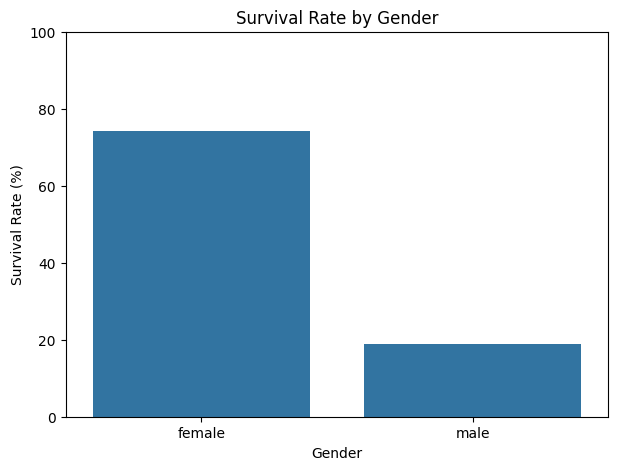

In [22]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_survival.index,
    y=gender_survival.values
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

plt.show()

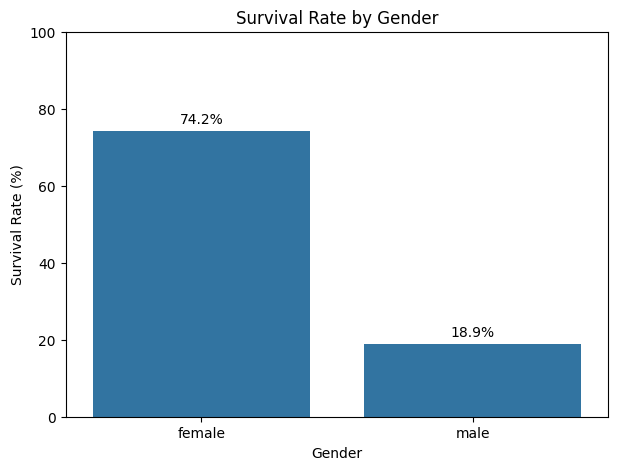

In [23]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=gender_survival.index,
    y=gender_survival.values
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(gender_survival.values):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

### Observation

Female passengers had a much higher survival rate than male passengers. Approximately 74.2% of female passengers survived, compared with around 18.9% of male passengers. This shows a strong relationship between gender and survival in the Titanic dataset, with female passengers having a significantly higher chance of survival.

## Question 3 – Which Passenger Class Had the Highest Survival Rate?

This analysis compares the survival rates of passengers across different passenger classes to determine whether passenger class was associated with survival.

In [24]:
class_survival = df.groupby("Passenger_Class")["Survived"].mean() * 100

class_survival

,Survived
Passenger_Class,
1,62.962963
2,47.282609
3,24.236253


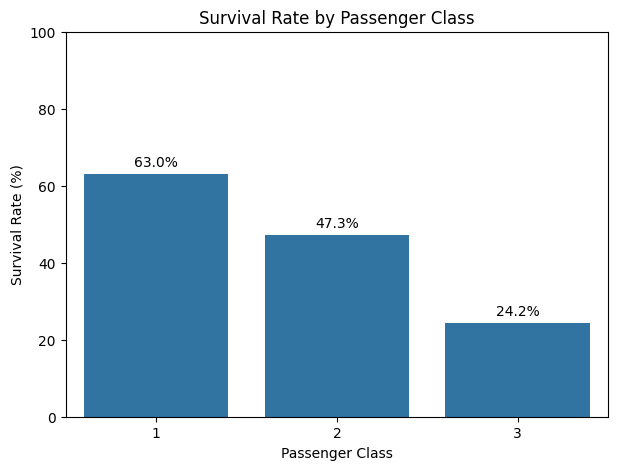

In [25]:

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=class_survival.index,
    y=class_survival.values
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(class_survival.values):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

### Observation

First-class passengers had the highest survival rate, followed by second-class passengers. Third-class passengers had the lowest survival rate. This suggests that passenger class was strongly associated with survival, with passengers in higher classes having better survival outcomes.

## Question 4 – Does Age Affect Survival?

This analysis examines the relationship between passenger age and survival. Both the age distribution of survivors and non-survivors and the survival patterns across different age groups are considered.

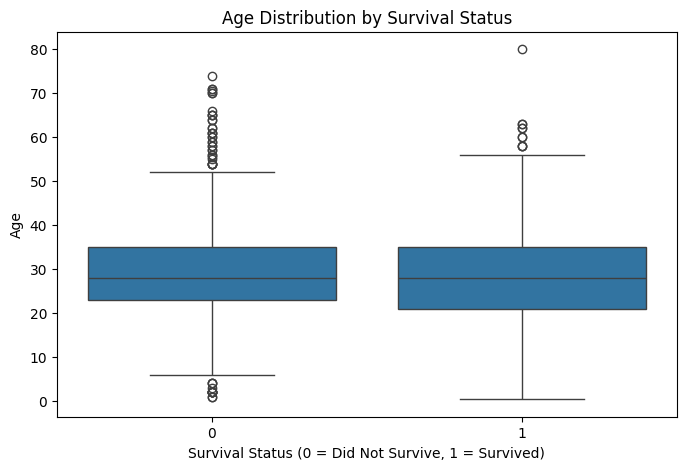

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Survived",
    y="Age",
    data=df
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Age")

plt.show()

In [27]:
age_survival = df.groupby("Survived")["Age"].mean()

age_survival

,Age
Survived,
0,30.028233
1,28.291433


In [28]:
age_group_survival = df.groupby("AgeGroup")["Survived"].mean() * 100

age_group_survival

,Survived
AgeGroup,
Adult,36.519258
Child,57.971014
Senior Citizen,26.923077
Teenager,41.052632


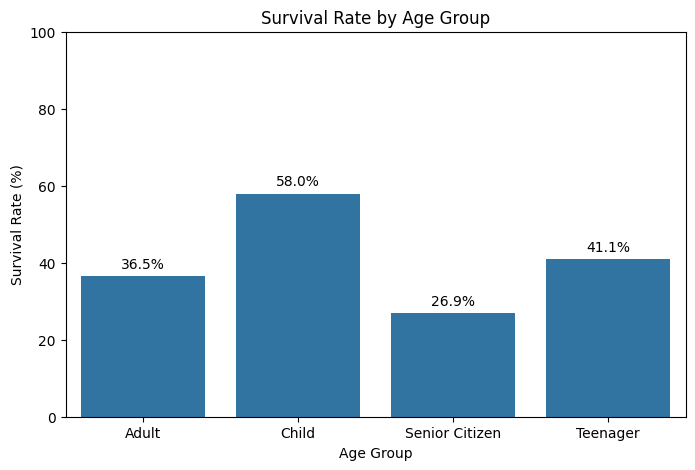

In [29]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=age_group_survival.index,
    y=age_group_survival.values
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(age_group_survival.values):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

### Observation

The average age of survivors (28.29 years) was slightly lower than that of non-survivors (30.03 years), indicating a small difference in average age. However, the age-group analysis shows a clearer pattern: children had the highest survival rate at 57.97%, while senior citizens had the lowest at 26.92%. Teenagers and adults had survival rates of 41.05% and 36.52%, respectively. This suggests that age group had some influence on survival, with younger passengers generally showing higher survival rates.

## Question 5 – Does Fare Influence Survival?

This analysis examines whether ticket fare was associated with passenger survival. Survival rates will be compared across different fare levels using numerical analysis and visualization.

In [32]:
fare_survival = df.groupby("Survived")["Fare"].mean()

fare_survival

,Fare
Survived,
0,22.117887
1,48.395408


In [35]:
fare_category_survival = df.groupby("FareCategory")["Survived"].mean() * 100

fare_category_survival

,Survived
FareCategory,
High Fare,68.125000
Low Fare,27.766990
Medium Fare,41.666667


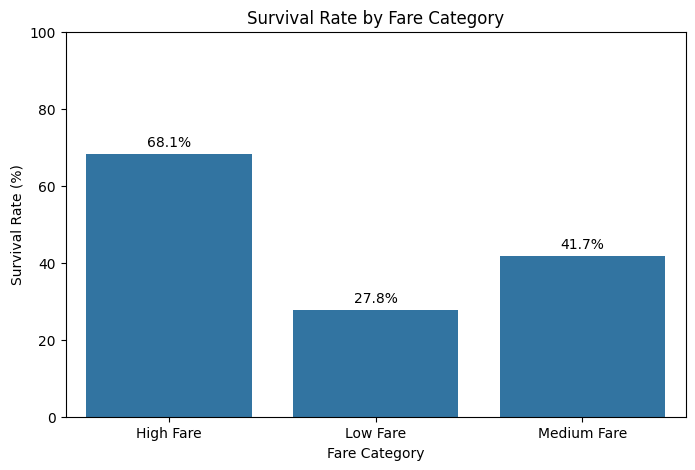

In [36]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=fare_category_survival.index,
    y=fare_category_survival.values
)

plt.title("Survival Rate by Fare Category")
plt.xlabel("Fare Category")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(fare_category_survival.values):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

### Observation

Passengers who paid higher fares generally had higher survival rates. The High Fare category had the highest survival rate at 68.13%, followed by the Medium Fare category at 41.67%, while the Low Fare category had the lowest survival rate at 27.77%. The average fare was also higher among survivors (48.40) than non-survivors (22.12). This suggests a positive association between fare level and survival, although fare may also be related to other factors such as passenger class.

## Question 6 – Did Passengers Travelling Alone Survive More Often?

This analysis compares the survival rates of passengers travelling alone with those travelling with family members. The `IsAlone` feature created during feature engineering is used for this analysis.

In [37]:
alone_survival = df.groupby("IsAlone")["Survived"].mean() * 100

alone_survival

,Survived
IsAlone,
No,50.564972
Yes,30.353818


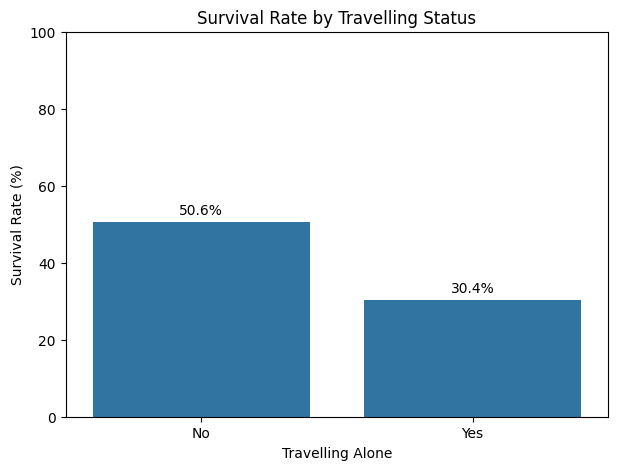

In [38]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=alone_survival.index,
    y=alone_survival.values
)

plt.title("Survival Rate by Travelling Status")
plt.xlabel("Travelling Alone")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(alone_survival.values):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

### Observation

Passengers travelling with family had a higher survival rate than passengers travelling alone. The survival rate for passengers travelling with family was 50.56%, compared with 30.35% for passengers travelling alone. This suggests that travelling with family was associated with better survival outcomes in the Titanic dataset.

## Question 7 – Which Embarkation Port Had the Highest Survival Rate?

This analysis compares the survival rates of passengers based on their embarkation port. It aims to determine whether survival outcomes differed among passengers who boarded the Titanic from different ports.

In [39]:
embarked_survival = df.groupby("Embarked")["Survived"].mean() * 100

embarked_survival

,Survived
Embarked,
C,55.357143
Q,38.961039
S,33.900929


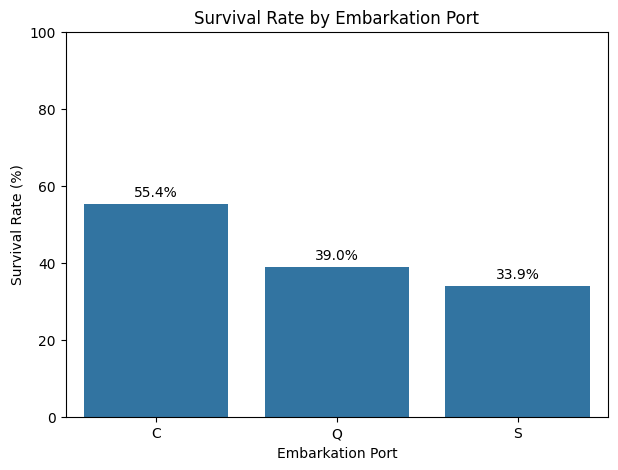

In [40]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=embarked_survival.index,
    y=embarked_survival.values
)

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(embarked_survival.values):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

### Observation

Passengers who embarked from Cherbourg (C) had the highest survival rate at 55.36%, followed by Queenstown (Q) at 38.96%. Southampton (S) had the lowest survival rate at 33.90%. This shows that survival rates differed across embarkation ports. However, the port itself may not directly explain survival, as other factors such as passenger class and fare could also contribute to these differences.

## Question 8 – What Is the Relationship Between Passenger Class and Fare?

This analysis examines the relationship between passenger class and ticket fare. A box plot is used to compare the distribution of fares across the three passenger classes.

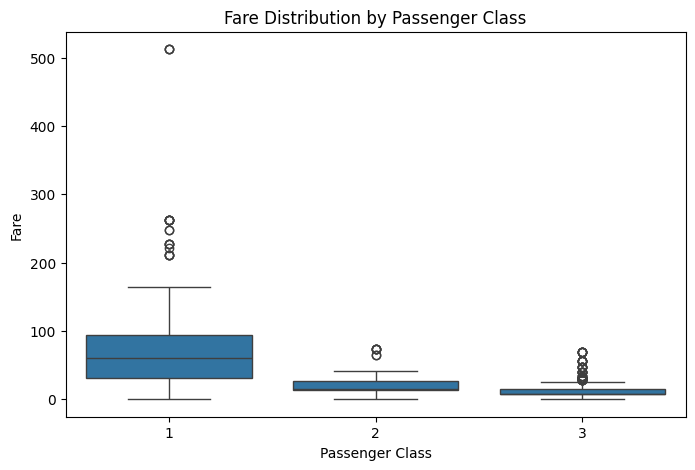

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Passenger_Class",
    y="Fare",
    data=df
)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.show()

In [42]:
class_fare = df.groupby("Passenger_Class")["Fare"].mean()

class_fare

,Fare
Passenger_Class,
1,84.154687
2,20.662183
3,13.675550


### Observation

The analysis shows a clear relationship between passenger class and ticket fare. First-class passengers paid the highest average fare of 84.15, while second-class passengers paid an average of 20.66 and third-class passengers paid the lowest average fare of 13.68. The box plot also shows that fare values were generally higher for first-class passengers. This relationship helps explain why higher fare levels were associated with higher survival rates in earlier analyses.

## Question 9 – Correlation Heatmap

A correlation heatmap is created to examine the relationships between numerical variables in the Titanic dataset. The heatmap helps identify strong positive and negative relationships and provides an overview of how different numerical features are related to each other.

In [43]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Passenger_ID,Survived,Passenger_Class,Age,Siblings_Spouses,Parents_Children,Fare,FamilySize
Passenger_ID,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639
Passenger_Class,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619
Siblings_Spouses,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712
Parents_Children,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138
FamilySize,-0.040143,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000


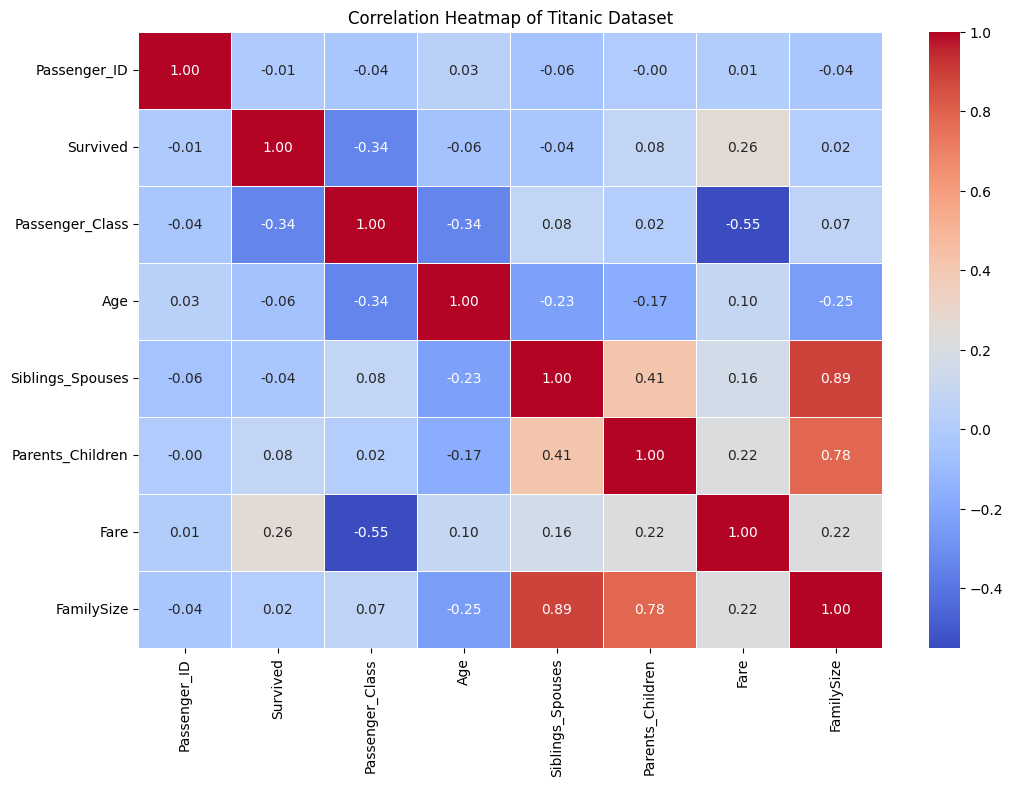

In [44]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Titanic Dataset")

plt.show()

### Observation

The correlation heatmap shows several important relationships among the numerical features. The strongest positive correlation between different variables is between Siblings_Spouses and FamilySize (0.89), followed by Parents_Children and FamilySize (0.78). This is expected because FamilySize was created using these two variables.

The strongest negative correlation is between Passenger_Class and Fare (-0.55). Since Passenger_Class uses 1 for first class and 3 for third class, this indicates that higher passenger classes generally had higher fares. Passenger_Class also had a negative correlation with Survived (-0.34), while Fare had a positive correlation with Survived (0.26). These relationships support the earlier findings that passenger class and fare were associated with survival outcomes.

## Question 10 – Does Family Size Affect Survival?

This analysis examines whether the number of family members travelling with a passenger was associated with their survival. The FamilySize feature created during feature engineering is used for this analysis.

In [45]:
family_size_survival = df.groupby("FamilySize")["Survived"].mean() * 100

family_size_survival

,Survived
FamilySize,
1,30.353818
2,55.279503
3,57.843137
4,72.413793
5,20.000000
6,13.636364
7,33.333333
8,0.000000
11,0.000000


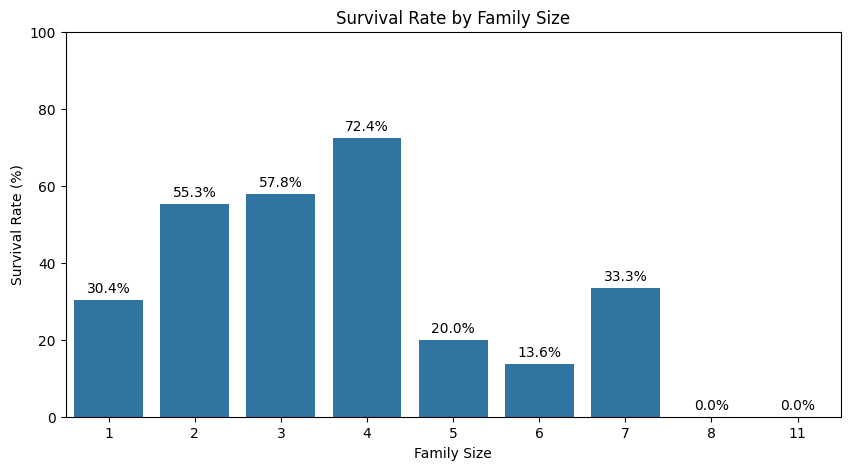

In [46]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=family_size_survival.index,
    y=family_size_survival.values
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(family_size_survival.values):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

In [47]:
family_size_counts = df["FamilySize"].value_counts().sort_index()

family_size_counts

,count
FamilySize,
1,537
2,161
3,102
4,29
5,15
6,22
7,12
8,6
11,7


### Observation

The analysis shows that passengers travelling with small to moderate family groups generally had higher survival rates than passengers travelling alone or in very large groups. Passengers with a family size of 4 had the highest survival rate at 72.41%, followed by family sizes of 3 and 2 with survival rates of 57.84% and 55.28%, respectively. Passengers travelling alone had a survival rate of 30.35%. Larger family groups, particularly sizes 5 and 6, had considerably lower survival rates. Family sizes of 8 and 11 had a 0% survival rate, but these groups contained very few passengers, so these results should be interpreted with caution.

# Part 4 – Statistical Analysis

Statistical analysis is performed to summarize the main characteristics of selected numerical variables. Mean, median, mode, and standard deviation are calculated for Age, Fare, and FamilySize to better understand their distributions.

## Statistical Measures for Selected Numerical Features

In [48]:
statistical_columns = ["Age", "Fare", "FamilySize"]

for column in statistical_columns:
    print(f"\n{column}")
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Mode:", df[column].mode()[0])
    print("Standard Deviation:", df[column].std())


Age
Mean: 29.36158249158249
Median: 28.0
Mode: 28.0
Standard Deviation: 13.019696550973194

Fare
Mean: 32.204207968574636
Median: 14.4542
Mode: 8.05
Standard Deviation: 49.693428597180905

FamilySize
Mean: 1.904601571268238
Median: 1.0
Mode: 1
Standard Deviation: 1.6134585413550788


### Statistical Analysis Interpretation

**Age:**  
The average age of passengers was 29.36 years, while the median and mode were both 28 years. This indicates that the typical passenger was around 28–29 years old. The standard deviation of 13.02 shows that passenger ages had considerable variation around the mean.

**Fare:**  
The average fare was 32.20, while the median was 14.45 and the mode was 8.05. The mean being considerably higher than the median suggests that some passengers paid much higher fares, which increased the average. The standard deviation of 49.69 indicates a high level of variation in fares.

**FamilySize:**  
The average family size was 1.90, while both the median and mode were 1. This indicates that many passengers were travelling alone. The standard deviation of 1.61 shows that family sizes varied, but most passengers had relatively small family groups.

# Part 5 – Dashboard

This dashboard summarizes the main patterns found in the Titanic dataset using key visualizations.

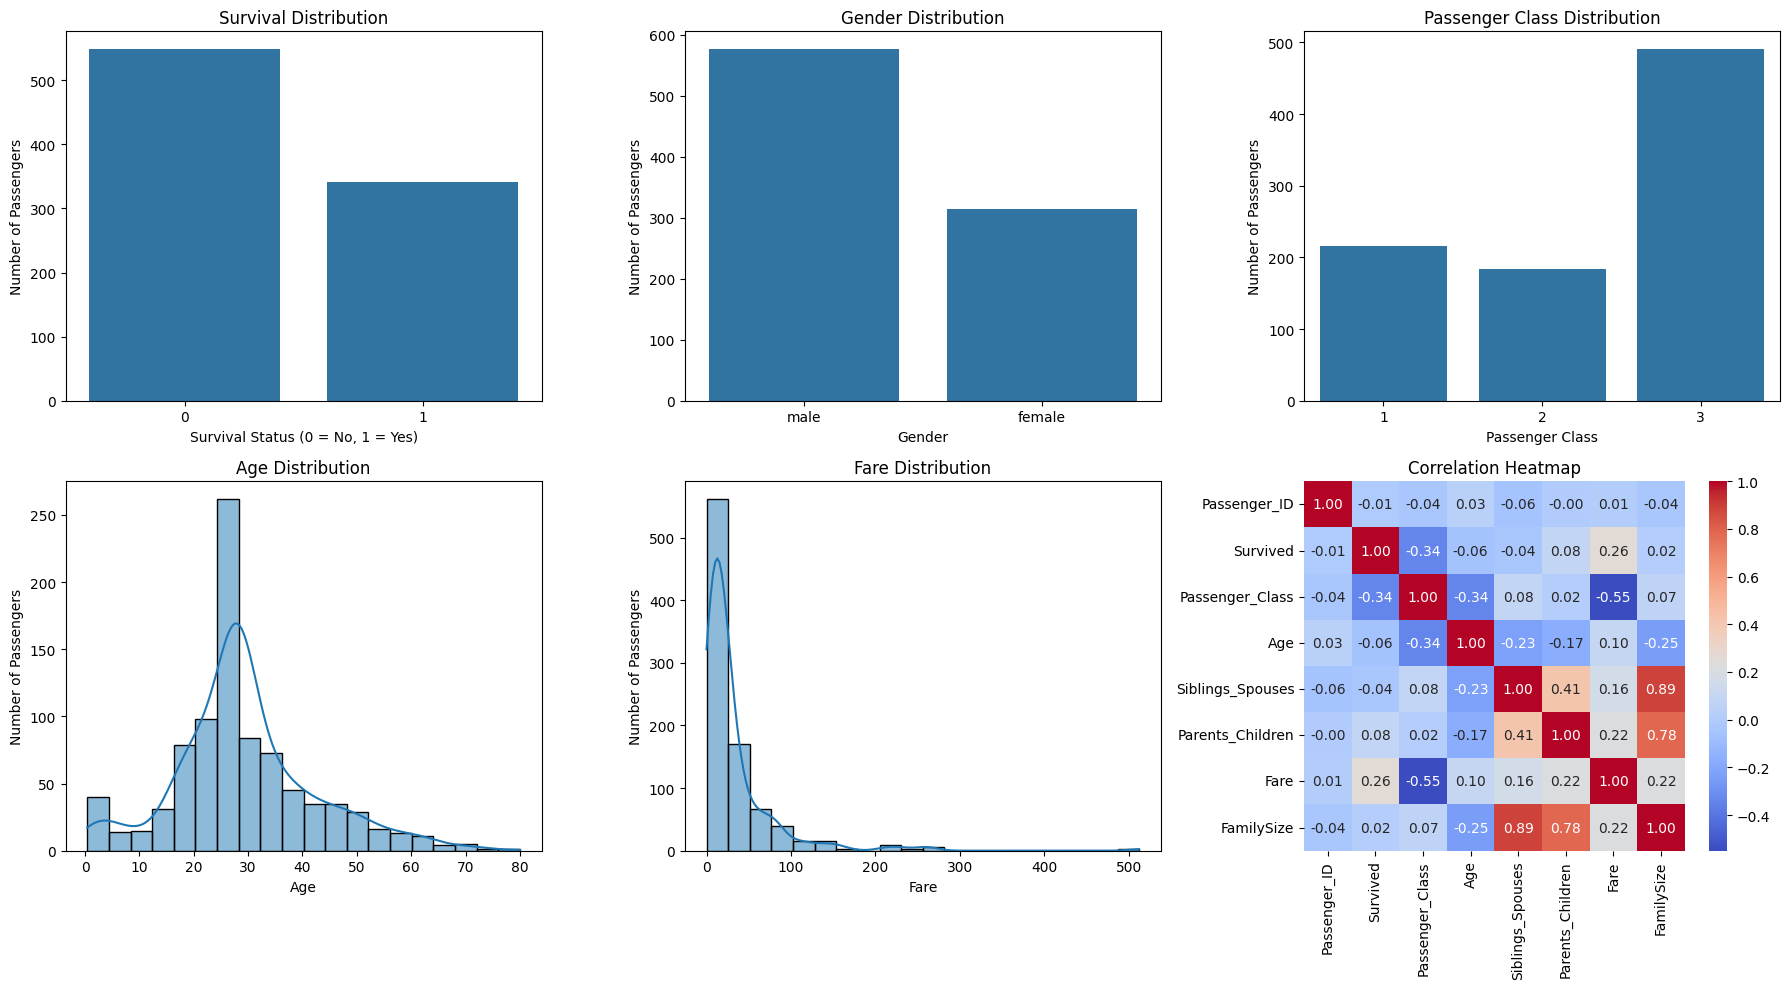

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Survival Distribution
sns.countplot(x="Survived", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Survival Distribution")
axes[0, 0].set_xlabel("Survival Status (0 = No, 1 = Yes)")
axes[0, 0].set_ylabel("Number of Passengers")


# 2. Gender Distribution
sns.countplot(x="Sex", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Number of Passengers")


# 3. Passenger Class Distribution
sns.countplot(x="Passenger_Class", data=df, ax=axes[0, 2])
axes[0, 2].set_title("Passenger Class Distribution")
axes[0, 2].set_xlabel("Passenger Class")
axes[0, 2].set_ylabel("Number of Passengers")


# 4. Age Distribution
sns.histplot(df["Age"], bins=20, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Age Distribution")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Number of Passengers")


# 5. Fare Distribution
sns.histplot(df["Fare"], bins=20, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Fare Distribution")
axes[1, 1].set_xlabel("Fare")
axes[1, 1].set_ylabel("Number of Passengers")


# 6. Correlation Heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=axes[1, 2]
)
axes[1, 2].set_title("Correlation Heatmap")


plt.tight_layout()
plt.show()

### Dashboard Summary

The dashboard provides a visual summary of passenger survival, gender, passenger class, age, fare, and correlations among numerical features. It brings together the main findings from the EDA into one view.

# Part 6 – Business Insights

The following insights are based on the analysis and visualizations performed on the Titanic dataset.

### Key Business Insights

1. **Overall survival was relatively low:** 38.38% of passengers survived, while 61.62% did not survive.

2. **Gender had a strong association with survival:** Female passengers had a survival rate of 74.20%, compared with only 18.89% for male passengers.

3. **Passenger class was strongly related to survival:** First-class passengers had the highest survival rate at 62.96%, while third-class passengers had the lowest at 24.24%.

4. **Younger age groups generally had better survival outcomes:** Children had the highest survival rate at 57.97%, while senior citizens had the lowest at 26.92%.

5. **Higher fares were associated with higher survival:** Passengers in the High Fare category had a survival rate of 68.13%, compared with 27.77% for the Low Fare category.

6. **Passengers travelling with family had better survival outcomes:** Passengers travelling with family had a survival rate of 50.56%, compared with 30.35% for those travelling alone.

7. **Embarkation ports showed different survival rates:** Cherbourg had the highest survival rate at 55.36%, while Southampton had the lowest at 33.90%.

8. **Passenger class and fare were strongly related:** First-class passengers paid an average fare of 84.15, compared with 20.66 for second class and 13.68 for third class.

9. **Small to moderate family groups generally had better survival rates:** Family sizes of 2–4 showed higher survival rates, while larger groups generally had lower survival rates.

10. **Fare and passenger class showed noticeable relationships with survival:** Fare had a positive correlation with survival (0.26), while Passenger_Class had a negative correlation with survival (-0.34), indicating that higher-class passengers generally had better survival outcomes.

### Overall Finding

The analysis shows that survival was associated with several passenger characteristics, particularly gender, passenger class, fare, age group, and travelling status. Among these factors, gender and passenger class showed some of the clearest differences in survival rates.

# Part 7 – Business Recommendations

Based on the analysis, the following recommendations could help improve passenger safety and emergency planning.

### Recommendations

1. **Improve emergency support for vulnerable passengers:**  
   Special assistance should be provided to children, elderly passengers, and other passengers who may require additional help during an emergency.

2. **Strengthen safety planning across all passenger classes:**  
   Since lower passenger classes showed lower survival rates, emergency procedures and access to safety resources should be equally effective for passengers in every class.

3. **Improve family evacuation procedures:**  
   Since passengers travelling with family generally had better survival outcomes, organized family evacuation procedures could help passengers stay together and reduce confusion during emergencies.

4. **Provide additional assistance to passengers travelling alone:**  
   Passengers travelling alone had a lower survival rate than those travelling with family. Staff could provide additional guidance and assistance to passengers who do not have travelling companions.

5. **Use passenger information for emergency planning:**  
   Passenger characteristics such as age, class, family size, and travelling status can be considered when planning emergency assistance and evacuation procedures.